In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krupalpatel07/silver-market-intelligence-dataset/silver.csv


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/krupalpatel07/silver-market-intelligence-dataset/silver.csv")

In [4]:
df.set_index(['Date'],inplace = True)

# 1 Volatility Landscape Map

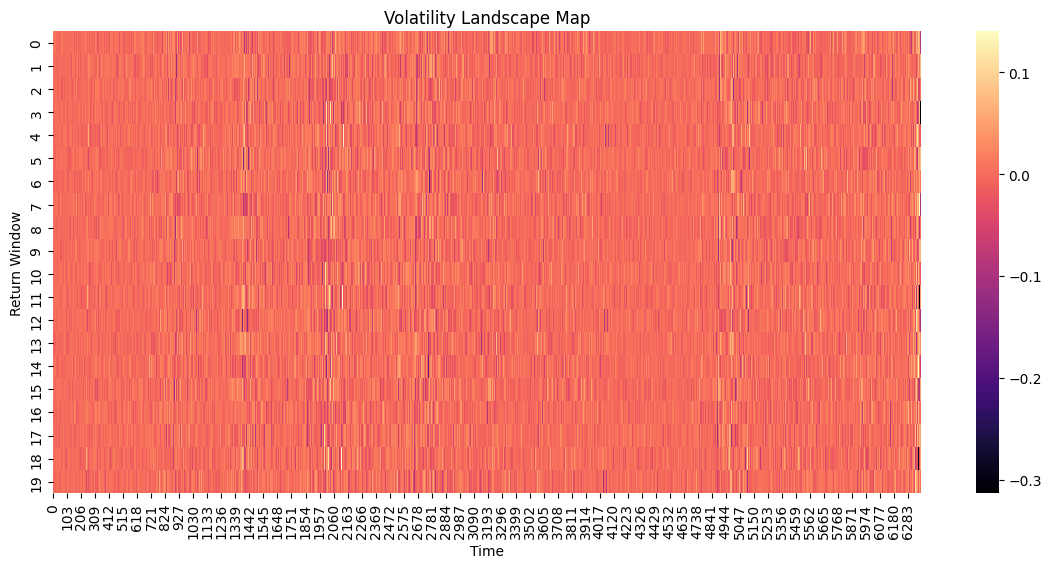

In [7]:
returns = df['Close'].pct_change()

vol_matrix = []

window = 20

for i in range(len(returns)-window):
    vol_matrix.append(returns[i:i+window].values)

vol_matrix = np.array(vol_matrix)

plt.figure(figsize=(14,6))

sns.heatmap(vol_matrix.T,
            cmap="magma",
            cbar=True)

plt.title("Volatility Landscape Map")

plt.xlabel("Time")

plt.ylabel("Return Window")

plt.show()

# 2 Market Phase Space Plot

/tmp/ipykernel_55/1906966436.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(returns, volatility,


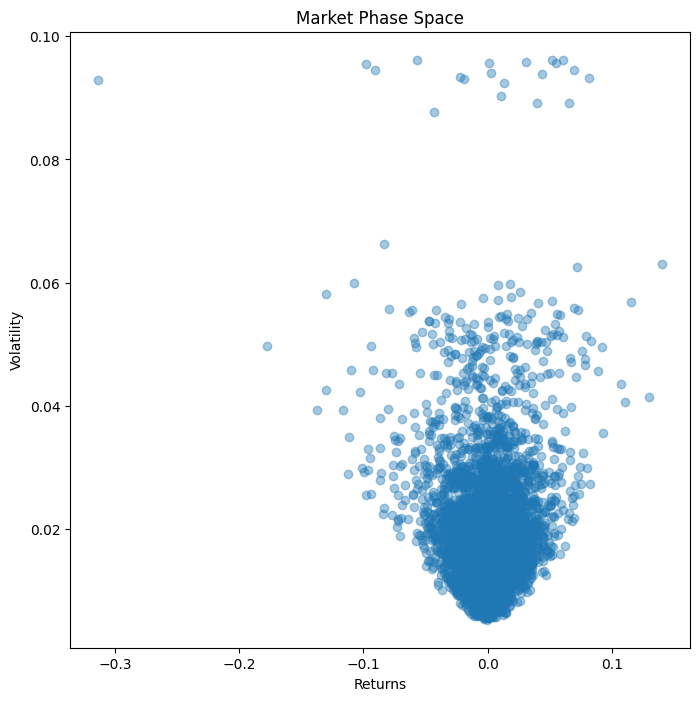

In [8]:
returns = df['Close'].pct_change()
volatility = returns.rolling(20).std()

plt.figure(figsize=(8,8))

plt.scatter(returns, volatility,
            alpha=0.4,
            cmap="viridis")

plt.xlabel("Returns")
plt.ylabel("Volatility")

plt.title("Market Phase Space")

plt.show()

# 3 Drawdown Waterfall Chart

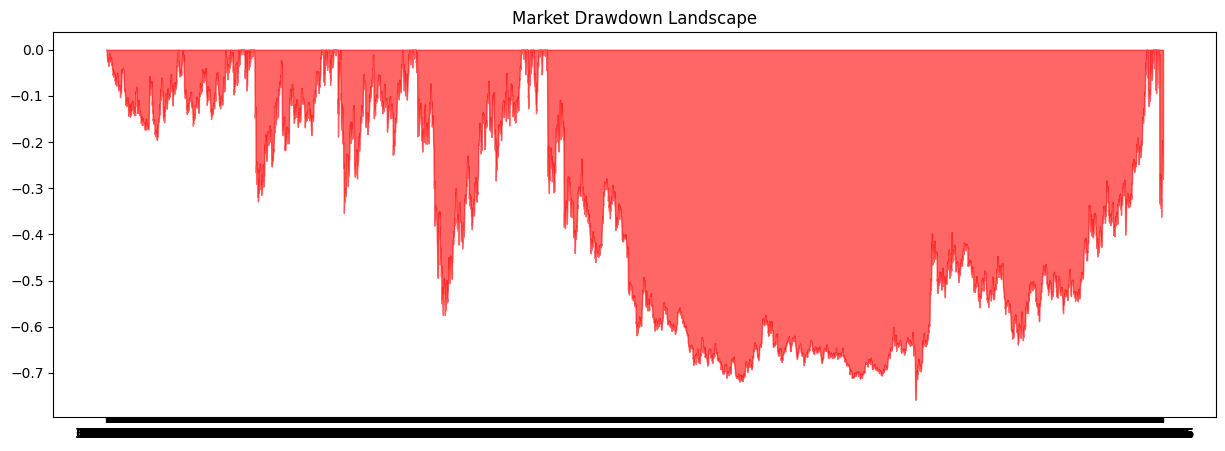

In [9]:
returns = df['Close'].pct_change()

cum = (1+returns).cumprod()

peak = cum.cummax()

drawdown = (cum-peak)/peak

plt.figure(figsize=(15,5))

plt.fill_between(drawdown.index,
                 drawdown,
                 color="red",
                 alpha=0.6)

plt.title("Market Drawdown Landscape")

plt.show()

# 4 Return Distribution Evolution

In [ ]:
returns = df['Close'].pct_change()

rolling_window = 250

dist_data = []

for i in range(len(returns)-rolling_window):
    dist_data.append(returns[i:i+rolling_window].std())

plt.figure(figsize=(15,5))

plt.plot(dist_data)

plt.title("Evolution of Market Risk")

plt.ylabel("Rolling Risk")

plt.show()

# 5 Price Momentum Surface (3D)

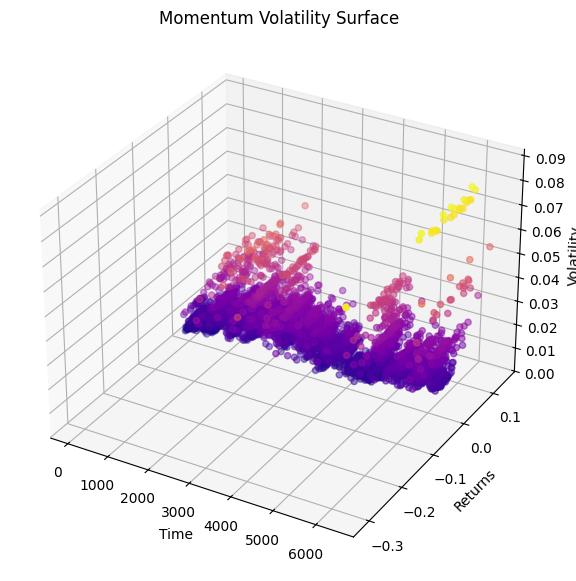

In [10]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

returns = df['Close'].pct_change()

x = np.arange(len(returns))

y = returns

z = returns.rolling(30).std()

ax.scatter(x,y,z,
           c=z,
           cmap="plasma")

ax.set_xlabel("Time")
ax.set_ylabel("Returns")
ax.set_zlabel("Volatility")

plt.title("Momentum Volatility Surface")

plt.show()